# License-Plate-Detection
# Name: SAADHANA A
# Reg no: 212225240126

In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [20]:
# Read image
img = cv2.imread('car_plate.png')

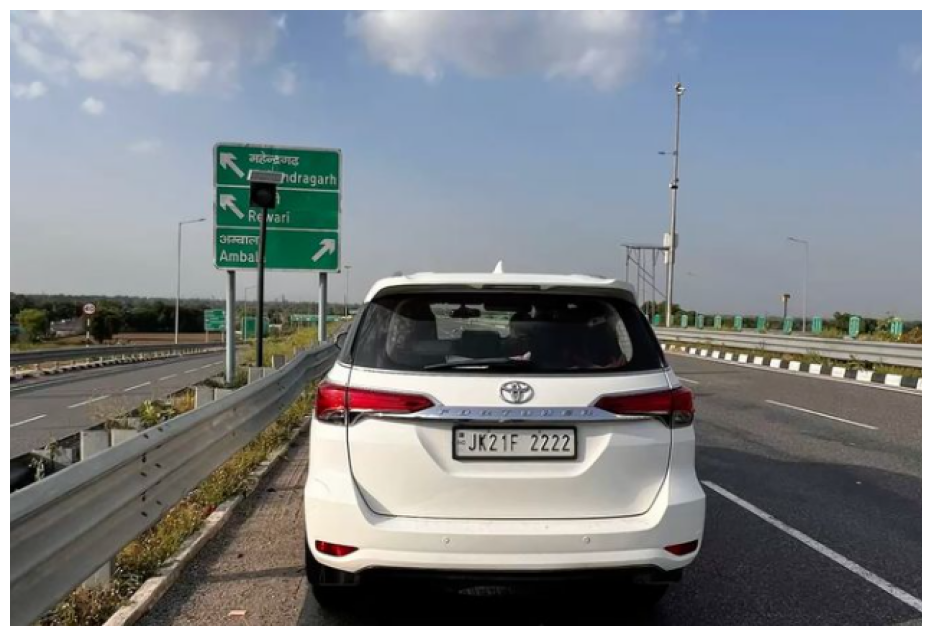

In [21]:
# Display image
def display(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
display(img)

In [22]:
# Load license plate Haar Cascade
plate_cascade = cv2.CascadeClassifier(
    'haarcascade_russian_plate_number.xml'
)

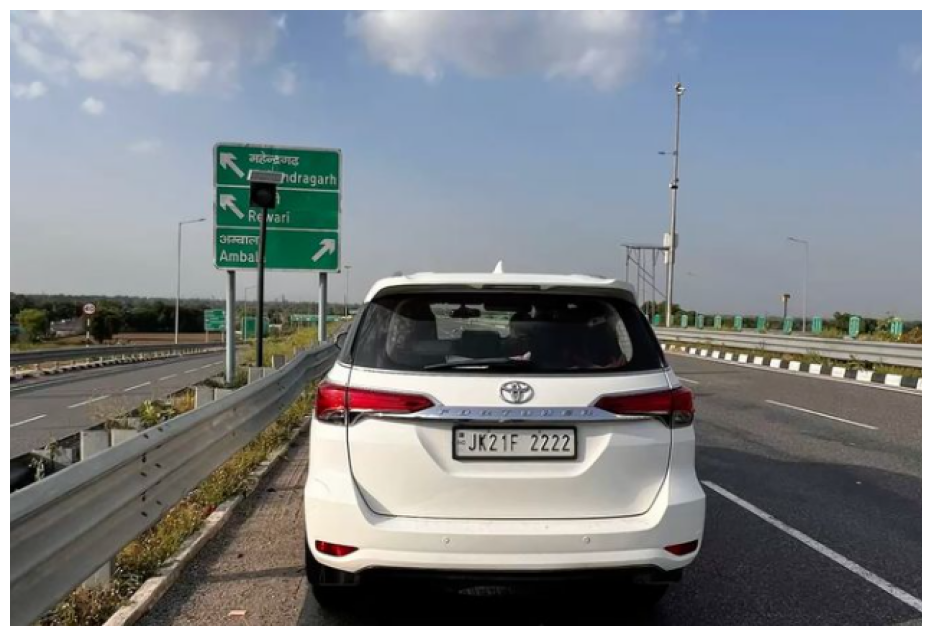

In [34]:
# Detect license plate and draw rectangle
def detect_plate(img):
    img_copy = img.copy()
    
    plates = plate_cascade.detectMultiScale(
        img_copy,
        scaleFactor=1.05,
        minNeighbors=3
    )

    for (x, y, w, h) in plates:
        cv2.rectangle(
            img_copy,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            3
        )

    return img_copy

# Display detected plate
result = detect_plate(img)
display(result)


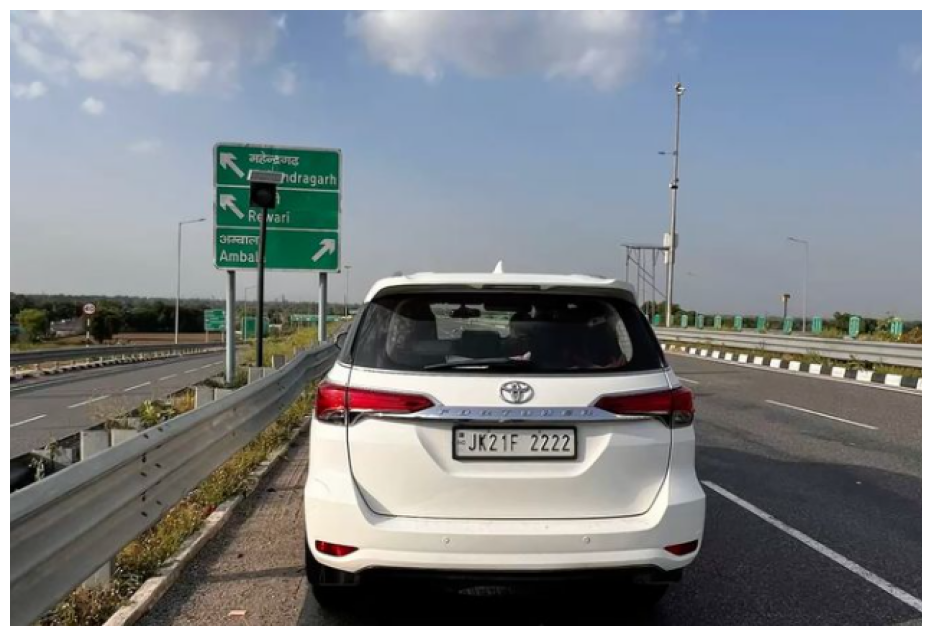

In [35]:
# Detect and blur license plate
def detect_and_blur_plate(img):
    img_copy = img.copy()

    plates = plate_cascade.detectMultiScale(
        img_copy,
        scaleFactor=1.1,
        minNeighbors=5
    )

    for (x, y, w, h) in plates:
        roi = img_copy[y:y+h, x:x+w]

        # Apply median blur
        blurred_roi = cv2.medianBlur(roi, 25)

        # Replace original ROI with blurred ROI
        img_copy[y:y+h, x:x+w] = blurred_roi

    return img_copy

# Display final result
result = detect_and_blur_plate(img)
display(result)